In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../02_Data/Raw/sp500_daily.csv", parse_dates=["date"])
df.head()

,date,Close,High,Low,Open,Volume
0,NaT,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
1,2020-01-02,3257.85009765625,3258.139892578125,3235.530029296875,3244.669921875,3459930000
2,2020-01-03,3234.85009765625,3246.14990234375,3222.340087890625,3226.360107421875,3484700000
3,2020-01-06,3246.280029296875,3246.840087890625,3214.639892578125,3217.550048828125,3702460000
4,2020-01-07,3237.179931640625,3244.909912109375,3232.429931640625,3241.860107421875,3435910000


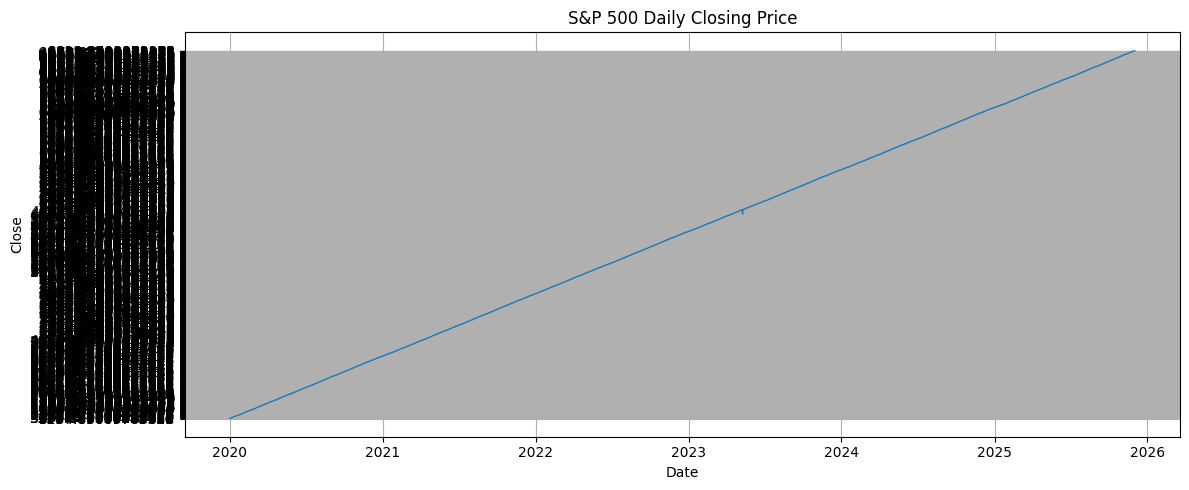

In [2]:
#Plot the closing price
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["Close"], linewidth=1)
plt.title("S&P 500 Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
#Check for anomalies (quick, professional)
print("Number of duplicated rows:", df.duplicated().sum())
print("Date range:", df['date'].min(), "→", df['date'].max())
print("Any large gaps (non-trading days excluded):")

df['diff'] = df['date'].diff().dt.days
print(df['diff'].value_counts().head())

Number of duplicated rows: 0
Date range: 2020-01-02 00:00:00 → 2025-12-02 00:00:00
Any large gaps (non-trading days excluded):
diff
1.0    1165
3.0     266
4.0      43
2.0      13
Name: count, dtype: int64


In [4]:
#Save cleaned version (for consistency)
df_clean = df.copy()

# Sort & ensure consistency
df_clean = df_clean.sort_values("date").reset_index(drop=True)

df_clean.to_csv("../02_Data/Processed/sp500_cleaned.csv", index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.
